<a href="https://colab.research.google.com/github/AnkushSharmaGuragai/AI-ML/blob/main/Worksheet1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
pip install pillow numpy matplotlib

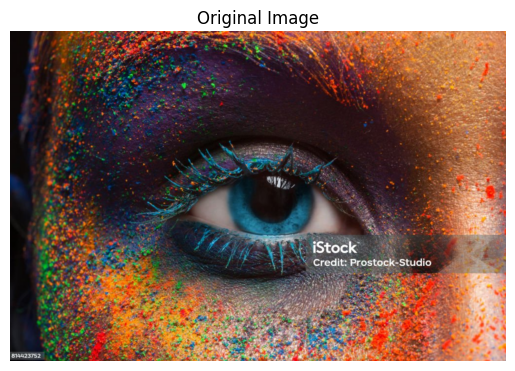

In [ ]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

# Step 1: Read the image
img = Image.open("/content/drive/MyDrive/AI ML/Data/eye.png")

# Step 2: Display the image
plt.imshow(img)
plt.title("Original Image")
plt.axis("off")
plt.show()

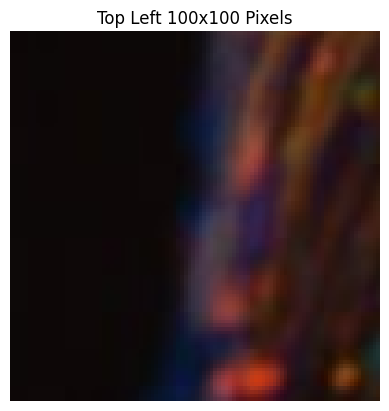

In [ ]:
img_array = np.array(img)
top_left = img_array[0:100, 0:100]

# Displaying
plt.imshow(top_left)
plt.title("Top Left 100x100 Pixels")
plt.axis("off")
plt.show()

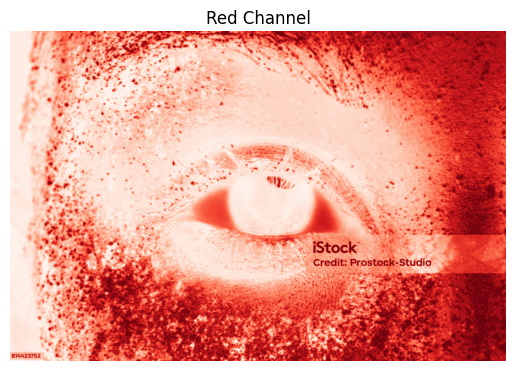

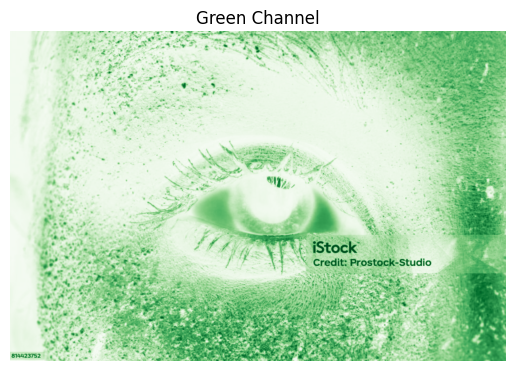

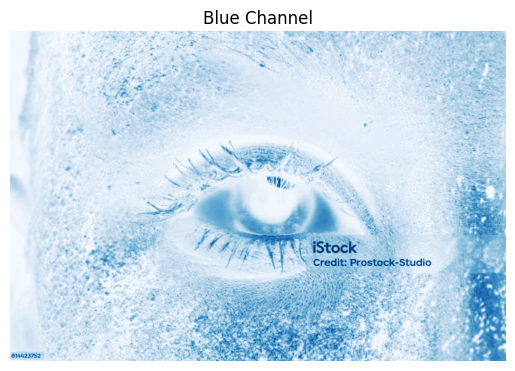

In [ ]:
# Separate channels
R = img_array[:, :, 0]
G = img_array[:, :, 1]
B = img_array[:, :, 2]

# Display Red channel
plt.imshow(R, cmap='Reds')
plt.title("Red Channel")
plt.axis("off")
plt.show()

# Display Green channel
plt.imshow(G, cmap='Greens')
plt.title("Green Channel")
plt.axis("off")
plt.show()

# Display Blue channel
plt.imshow(B, cmap='Blues')
plt.title("Blue Channel")
plt.axis("off")
plt.show()

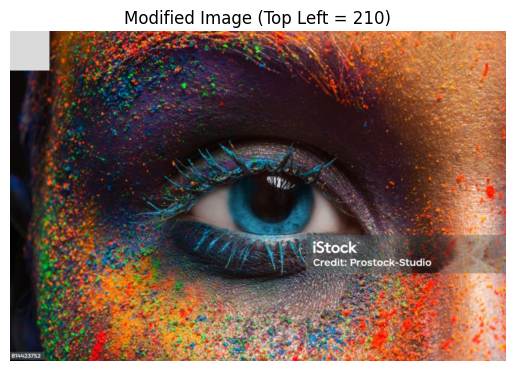

In [ ]:
modified = img_array.copy()
modified[0:100, 0:100] = 210

# Display
plt.imshow(modified)
plt.title("Modified Image (Top Left = 210)")
plt.axis("off")
plt.show()

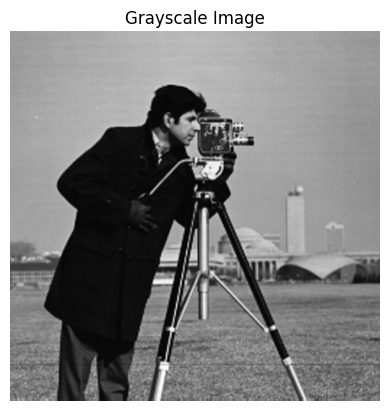

In [ ]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt


img = Image.open("/content/drive/MyDrive/AI ML/Data/cameraman.png")

# Display the grayscale image
plt.imshow(img, cmap="gray")
plt.title("Grayscale Image")
plt.axis("off")
plt.show()

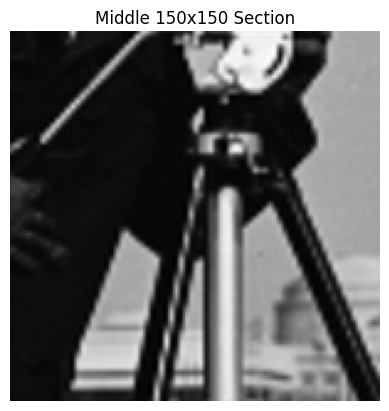

In [ ]:
# Convert image to numpy array
img_array = np.array(img)
height, width = img_array.shape
center_y = height // 2
center_x = width // 2
middle = img_array[center_y-75:center_y+75, center_x-75:center_x+75]

# Display cropped section
plt.imshow(middle, cmap="gray")
plt.title("Middle 150x150 Section")
plt.axis("off")
plt.show()

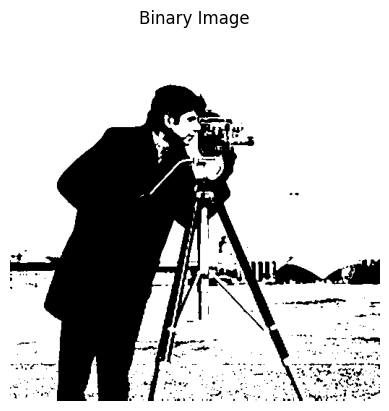

In [ ]:

binary = img_array.copy()

# Apply threshold
binary[binary < 100] = 0
binary[binary >= 100] = 255

# Display result
plt.imshow(binary, cmap="gray")
plt.title("Binary Image")
plt.axis("off")
plt.show()

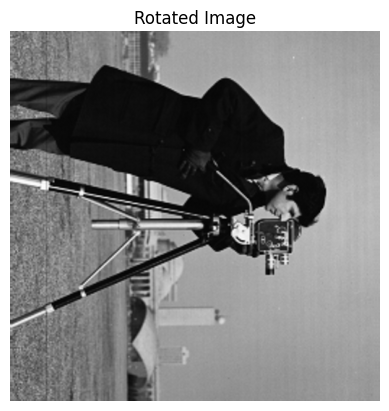

In [ ]:
# Rotate image 90 degrees clockwise
rotated = img.rotate(-90)

# Display rotated image
plt.imshow(rotated, cmap="gray")
plt.title("Rotated Image")
plt.axis("off")
plt.show()

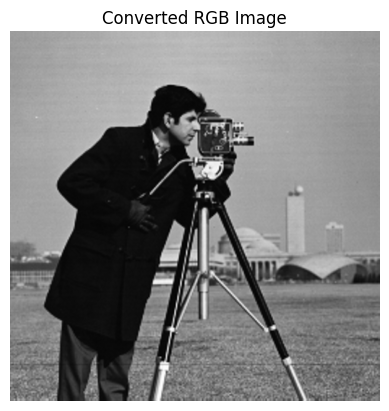

In [ ]:
# Convert grayscale array to RGB
rgb_image = np.stack((img_array,)*3, axis=-1)

# Display RGB image
plt.imshow(rgb_image)
plt.title("Converted RGB Image")
plt.axis("off")
plt.show()

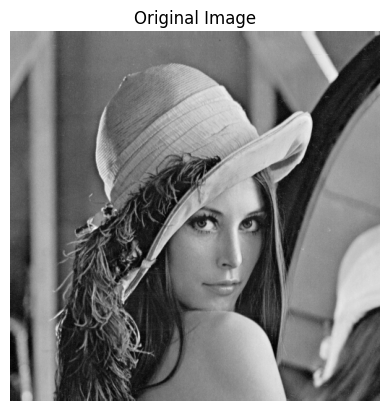

In [ ]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

# Load image
img = Image.open("/content/drive/MyDrive/AI ML/Data/lena_gray.gif").convert("L")

# Convert to numpy array
img_array = np.array(img)

# Show image
plt.imshow(img_array, cmap='gray')
plt.title("Original Image")
plt.axis("off")
plt.show()

In [ ]:
# Calculate mean
mean = np.mean(img_array, axis=0)

# Center the data
centered_data = img_array - mean

In [ ]:
cov_matrix = np.cov(centered_data, rowvar=False)

In [ ]:
eigen_values, eigen_vectors = np.linalg.eig(cov_matrix)

In [ ]:
# Sort eigenvalues
sorted_index = np.argsort(eigen_values)[::-1]

sorted_eigenvalues = eigen_values[sorted_index]
sorted_eigenvectors = eigen_vectors[:, sorted_index]

In [ ]:
explained_variance = sorted_eigenvalues / np.sum(sorted_eigenvalues)

cumulative_variance = np.cumsum(explained_variance)

/usr/local/lib/python3.12/dist-packages/matplotlib/cbook.py:1709: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/usr/local/lib/python3.12/dist-packages/matplotlib/cbook.py:1345: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


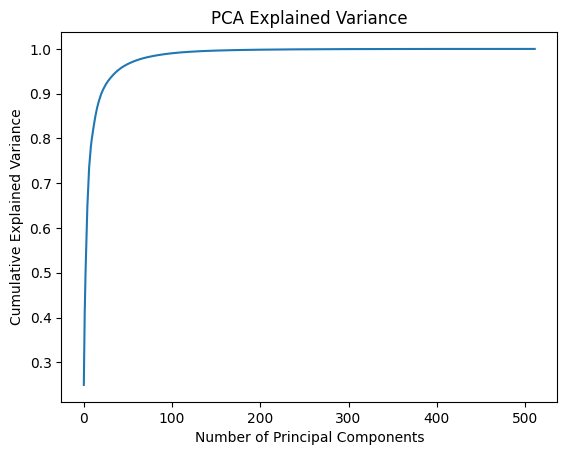

In [ ]:
plt.plot(cumulative_variance)
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Explained Variance")
plt.show()

In [ ]:
k = 50

principal_components = sorted_eigenvectors[:, :k]

In [ ]:
compressed = np.dot(centered_data, principal_components)

In [ ]:
reconstructed = np.dot(compressed, principal_components.T) + mean

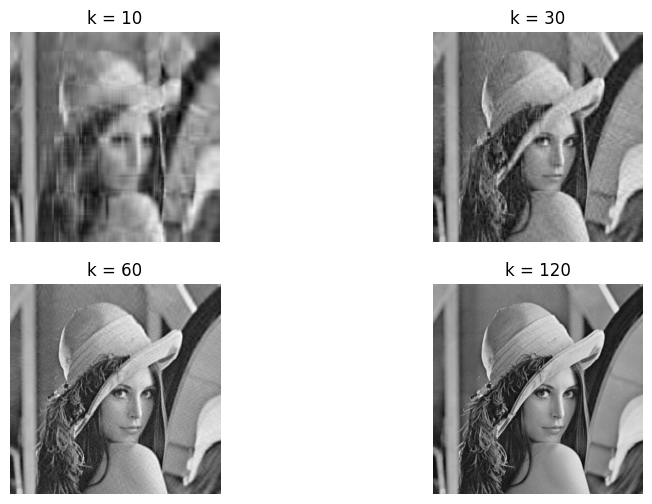

In [ ]:
ks = [10, 30, 60, 120]

plt.figure(figsize=(10,6))

for i,k in enumerate(ks):

    pc = sorted_eigenvectors[:, :k]

    compressed = np.dot(centered_data, pc)

    reconstructed = np.dot(compressed, pc.T) + mean

    plt.subplot(2,2,i+1)
    plt.imshow(reconstructed.real, cmap='gray') # Take the real part of the reconstructed image
    plt.title(f"k = {k}")
    plt.axis("off")

plt.show()